In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import urllib.parse
import warnings
from sklearn.model_selection import train_test_split,cross_val_score


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',None)
%matplotlib inline

In [4]:
load_dotenv()
def get_db_connection():

    user = os.getenv('MYSQL_USER')
    password = os.getenv('MYSQL_PASSWORD')
    host = os.getenv('MYSQL_HOST')
    port = os.getenv('MYSQL_PORT')
    database = os.getenv('MYSQL_DB')

    safe_password = urllib.parse.quote_plus(password)

    db_url = f"mysql+pymysql://{user}:{safe_password}@{host}:{port}/{database}"
    engine = create_engine(db_url)
    return engine

def query_data(query):
    try:
        engine = get_db_connection()
        df_result = pd.read_sql(query,con=engine)
        return df_result
    except Exception as e:
        print(f"Error in querying data: {e}")
        return None

In [5]:
data_query = """
select * from household_digital_products_expenditure

"""

df= query_data(data_query)

In [10]:
total_national_spend = sum(df['cost'] * df['calibration_weight'])
average_household_spend = total_national_spend/ sum(df['calibration_weight'])
print(total_national_spend)
print(round(average_household_spend,1))

549432628798.92456
92.9


In [11]:
print(df.head())

   index    newid reference_month  reference_year     ucc  cost  fam_size  \
0     29  4214954         January            2020  270102    45         1   
1     30  4214954        February            2020  270102    45         1   
2     31  4214954           March            2020  270102    45         1   
3     32  4214954         January            2020  690114   120         1   
4     33  4214954        February            2020  690114   120         1   

   family_income_before_tax_last_12_month  calibration_weight  \
0                                   10000           23581.165   
1                                   10000           23581.165   
2                                   10000           23581.165   
3                                   10000           23581.165   
4                                   10000           23581.165   

   number_of_earners interview_month  interview_year region sex_ref  \
0                  1           April            2020   West    Male   
1   

Define column groups

In [12]:
categorical_cols = ['region','product_category','state','division']

Define numerical group

In [41]:
numerical_cols = ['fam_size','total_salary_income_before_deduction','family_income_before_tax_last_12_month']
cap = df['cost'].quantile(0.99)
df['cost'] = df['cost'].clip(upper=cap)

sub-pipeline for numerical features

In [42]:
numerical_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler()),
])

sub-pipeline for categorical features

In [43]:
categorical_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('encoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

combine them

In [44]:
preprocessor = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
])

full pipeline + model

In [53]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=30,
    random_state=42

                          ))
])

Train & evaluate the model

In [54]:
x = df[numerical_cols + categorical_cols]
y = df['cost']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

pipeline.fit(x_train,y_train)

y_pred = pipeline.predict(x_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562
[LightGBM] [Info] Number of data points in the train set: 209973, number of used features: 7
[LightGBM] [Info] Start training from score 84.955252


Cross-Validation for model

In [55]:
scores = cross_val_score(pipeline,x,y,cv=5,scoring='neg_mean_absolute_error')
print(f"Mean MAE: ${-scores.mean():.2f} (+/- {scores.mean():.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562
[LightGBM] [Info] Number of data points in the train set: 209973, number of used features: 7
[LightGBM] [Info] Start training from score 85.273654
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562
[LightGBM] [Info] Number of data points in the train set: 209973, number of used features: 7
[LightGBM] [Info] Start training from score 84.577587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

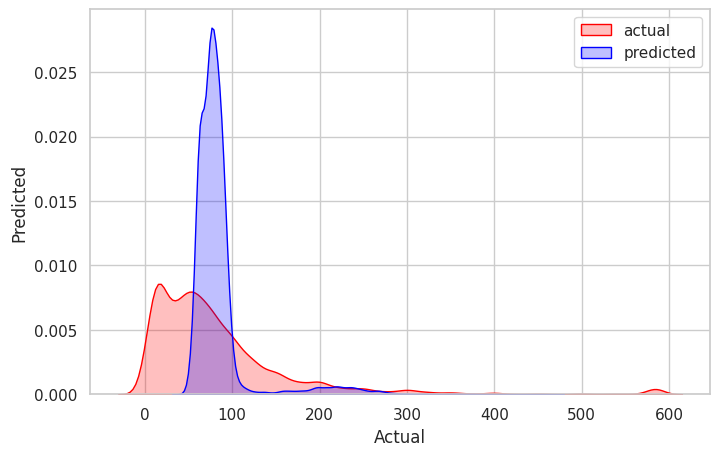

In [56]:
plt.figure(figsize=(8,5))
sns.kdeplot(y_test,color='red',fill=True,label='actual')
sns.kdeplot(y_pred,color='blue',fill=True,label='predicted')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

ValueError: 'block' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

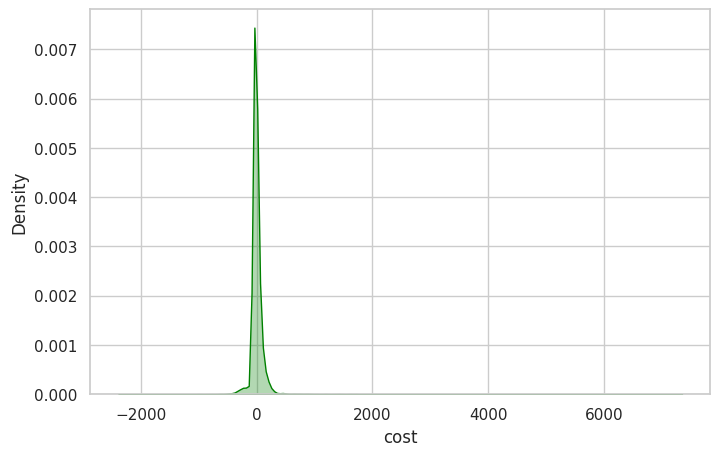

In [31]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

sns.kdeplot(errors,fill=True,alpha=0.3,color='green')
plt.axvline(x=0,color='block',linestyle='--',label='mean')
plt.axvline(x=errors.mean(),color='white',linestyle='--',label=f'Mean error: ${errors.mean():.2f}')

plt.xlabel('Prediction Error ($)')
plt.ylabel('Density')
plt.title('KDE: Prediction Error Distribution')
plt.legend()
plt.show()
